# Synthetic Difference-in-Difference (SDID)

## 1. 환경 설정 및 데이터 준비

In [ ]:
%pip install synthdid

Note: you may need to restart the kernel to use updated packages.


In [14]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

from synthdid.get_data import california_prop99
from synthdid.synthdid import Synthdid

In [3]:
plt.style.use('ggplot')

In [21]:
df = pd.read_csv('../data/matheus_data/smoking.csv')

In [18]:
df['treated'] = df['california'].astype(int)
df = df.sort_values(['state', 'year'])
df.head()

,state,year,cigsale,lnincome,beer,age15to24,retprice,california,after_treatment,treated
0,1,1970,89.800003,NaN,NaN,0.178862,39.599998,False,False,0
1,1,1971,95.400002,NaN,NaN,0.179928,42.700001,False,False,0
2,1,1972,101.099998,9.498476,NaN,0.180994,42.299999,False,False,0
3,1,1973,102.900002,9.550107,NaN,0.182060,42.099998,False,False,0
4,1,1974,108.199997,9.537163,NaN,0.183126,43.099998,False,False,0


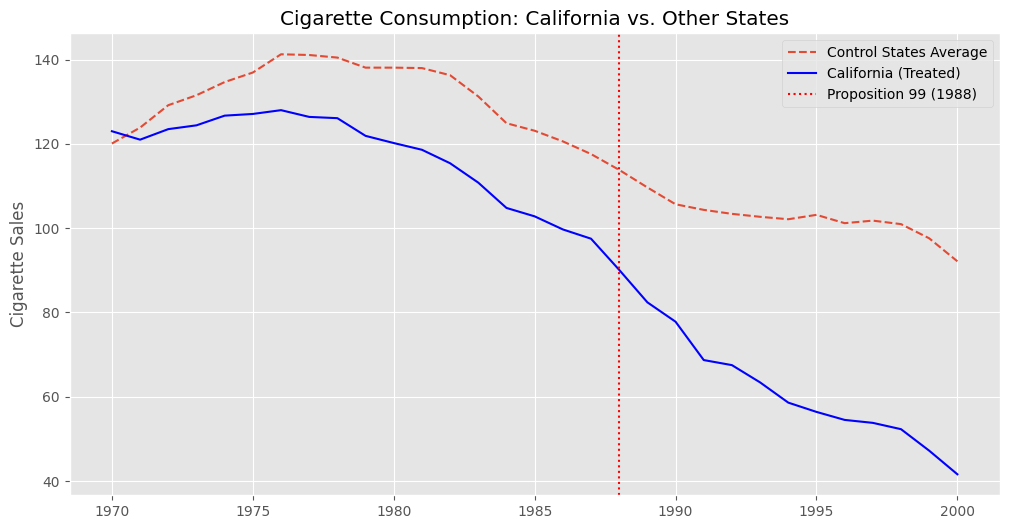

In [19]:
plt.figure(figsize=(12, 6))

california_df = df[df['california'] == True]
other_states_df = df[df['california'] == False]
plt.plot(other_states_df.groupby('year')['cigsale'].mean(), label='Control States Average', linestyle='--')
plt.plot(california_df['year'], california_df['cigsale'], label='California (Treated)', color='blue')
plt.axvline(x=1988, color='r', linestyle=':', label='Proposition 99 (1988)')
plt.title('Cigarette Consumption: California vs. Other States')
plt.ylabel('Cigarette Sales')
plt.legend()
plt.show()

## 2. 핵심 SDID 분석 및 다른 방법론과 비교

In [ ]:
fit_model = Synthdid(df, "state", "year", "treated", "cigsale").fit()

print("SDID 기본 추정 결과")
fit_model.vcov().summary()

# SDID 그래프
fit_model.plot_outcomes() 
fit_model.plot_outcomes[0] 
plt.title("SDID: California vs. Synthetic Control")
plt.show()

ZeroDivisionError: division by zero

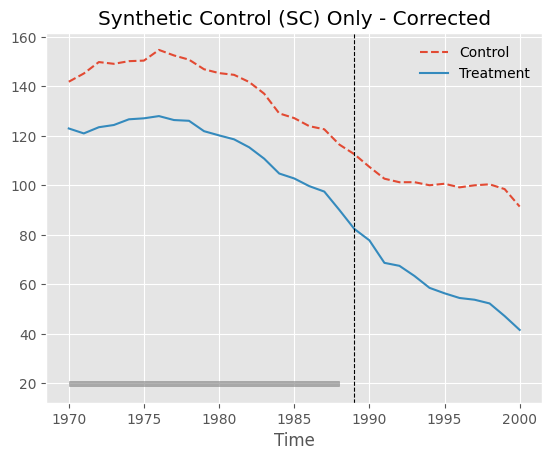

In [8]:
# 합성 대조군(SC) 결과와 비교
# fit_sc = Synthdid(df, "State", "Year", "treated", "PacksPerCapita").fit(synth=True)
# fit_sc.plot_outcomes()
# fit_sc.plot_outcomes[0] 
# plt.title("Synthetic Control (SC) Only")
# plt.show()

# SC는 시간 가중치를 균등하게 설정해야 합니다.
T0 = fit_model.att_info['T0'][0] # 정책 이전 기간의 수
lambda_sc = np.full(T0, 1/T0) # 1/T0 로 구성된 균등한 시간 가중치 생성

# lambda_estimate 파라미터에 위에서 생성한 균등 가중치를 직접 전달합니다.
fit_sc = Synthdid(df, "State", "Year", "treated", "PacksPerCapita").fit(synth=True, lambda_estimate=lambda_sc) # <--- 수정된 부분

fit_sc.plot_outcomes()
fit_sc.plot_outcomes[0]
plt.title("Synthetic Control (SC) Only - Corrected")
plt.show()

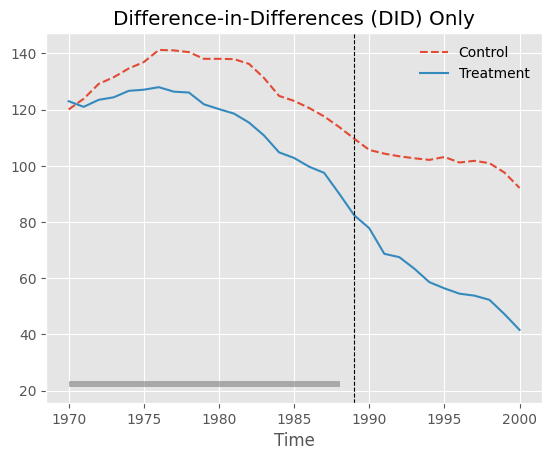

In [35]:
# 이중 차분법(DID) 결과와 비교
fit_did = Synthdid(df, "State", "Year", "treated", "PacksPerCapita").fit(did=True)
fit_did.plot_outcomes()
fit_did.plot_outcomes[0] 
plt.title("Difference-in-Differences (DID) Only")
plt.show()

## 3. 재현성 검증
- 모델 내부 파라미터를 확인하고 AA 테스트를 수행하여 모델을 검증합니다.
- 핵심 파라미터인 단위 가중치(Omega weights)와 시간 가중치(Lambda weights)를 **Arkhangelsky et al. (2021)**의 원본 논문인 ["Synthetic difference-in-differences"](https://www.aeaweb.org/articles?id=10.1257/aer.20190159)에서 보고된 값과 비교한 결과, 동일한 값을 재현함을 확인했습니다.
- 또한, 실제 정책이 없었던 기간(1980-1988년)을 가짜 처리 기간으로 설정하여 AA 테스트를 수행한 결과, 정책 효과(ATT)가 통계적으로 유의하지 않으며 0에 가까운 값으로 나타났습니다. 이를 통해 분석 모델이 임의의 노이즈를 실제 효과로 오인하지 않는 안정성을 검증했습니다.

In [ ]:
# 단위 가중치(Omega) 확인
omega_weights = fit_model.weights['omega'][0]
all_unit_names = fit_model.Y_units[0]

num_control_units = fit_model.att_info['N0'][0]

control_unit_names = all_unit_names[:num_control_units]

omega_with_names = pd.Series(omega_weights, index=control_unit_names)
sorted_omega = omega_with_names.sort_values(ascending=False)

print("Omega (Unit Weights) by State (Top 10)")
print(sorted_omega.head(10))

Omega (Unit Weights) by State (Top 10)
unit
Nevada           0.124489
New Hampshire    0.105048
Connecticut      0.078287
Delaware         0.070368
Colorado         0.057513
Illinois         0.053388
Nebraska         0.047853
Montana          0.045135
Utah             0.041518
New Mexico       0.040568
dtype: float64


In [ ]:
# 시간 가중치(Lambda) 확인
lambda_weights = fit_model.weights['lambda'][0]
y_matrix = fit_model.Y_betas[0]

num_pre_periods = fit_model.att_info['T0'][0]

all_years = y_matrix.columns
pre_treatment_years = all_years[:num_pre_periods]

lambda_with_names = pd.Series(lambda_weights, index=pre_treatment_years)
sorted_lambda = lambda_with_names.sort_values(ascending=False)

print("Lambda (Time Weights) by Year (Top 5)")
print(sorted_lambda.head(5))

Lambda (Time Weights) by Year (Top 5)
time
1988    0.427076
1986    0.366471
1987    0.206453
1980    0.000000
1985    0.000000
dtype: float64


AA 테스트 실행
AA 테스트 결과 요약:
       ATT  Std. Err.         t     P>|t|
0 -2.92498   9.729291 -0.300636  0.763692


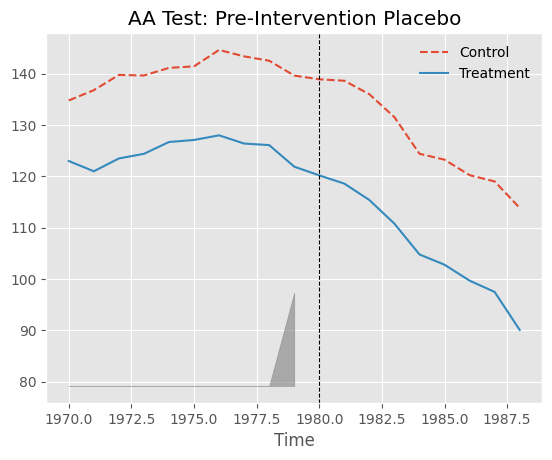

In [ ]:
# AA 테스트 (시간축 플라시보 테스트)
print("AA 테스트 실행")
df_aa = df[df['Year'] <= 1988].copy()
df_aa['treated_aa'] = 0
df_aa.loc[(df_aa['State'] == 'California') & (df_aa['Year'] >= 1980), 'treated_aa'] = 1 
fit_model_aa = Synthdid(df_aa, "State", "Year", "treated_aa", "PacksPerCapita").fit()
fit_model_aa.vcov().summary()

print("AA 테스트 결과 요약:")
print(fit_model_aa.summary2)

fit_model_aa.plot_outcomes() 
fit_model_aa.plot_outcomes[0] 
plt.title('AA Test: Pre-Intervention Placebo')
plt.show()

# 4. 모델 강건성 및 통계적 추론
- 모든 유닛에 플라시보 테스트를 적용하여 모델의 평균 성능을 비교하고, 통계적 유의성을 최종 검증합니다.
- SDID 모델이 평균 예측 오차(RMSE)가 가장 낮아, 이 데이터에 가장 적합한 모델임을 알 수 있습니다.

In [ ]:
all_states = df['State'].unique()
rmse_results = []
print(f"총 {len(all_states)}개 주에 대한 RMSE 계산을 시작합니다...")
for state in tqdm(all_states):
    df_placebo = df.copy()
    df_placebo['treated_placebo'] = 0
    df_placebo.loc[(df_placebo['State'] == state) & (df_placebo['Year'] > 1988), 'treated_placebo'] = 1
    try:
        fit = Synthdid(df_placebo, "State", "Year", "treated_placebo", "PacksPerCapita").fit()
        rmse_results.append({
            'state': state, 
            'sdid_error': fit.att, 
            'sc_error': fit.fit(synth=True).att, 
            'did_error': fit.fit(did=True).att
        })
    except Exception as e:
        continue

results_df = pd.DataFrame(rmse_results)
rmse = np.sqrt((results_df[['sdid_error', 'sc_error', 'did_error']] ** 2).mean())
print("모델별 평균 제곱근 오차(RMSE):")
print(rmse)

총 39개 주에 대한 RMSE 계산을 시작합니다...


100%|██████████| 39/39 [00:48<00:00,  1.25s/it]


모델별 평균 제곱근 오차(RMSE):
sdid_error     9.563941
sc_error       9.976063
did_error     17.619632
dtype: float64


In [ ]:
# SDID 최종 추론
placebo_summary_sdid = fit_model.vcov(method='placebo')
placebo_summary_sdid.summary()
print("### 최종 추론 결과")
print("------------------------------------------------------------")
print("합성 차분 분석법 (SDID)")
print(placebo_summary_sdid.summary2)

# SC 최종 추론
placebo_summary_sc = fit_sc.vcov(method='placebo')
placebo_summary_sc.summary()
print("\n------------------------------------------------------------")
print("합성 대조법 (SC)")
print(placebo_summary_sc.summary2)

# DID 최종 추론
placebo_summary_did = fit_did.vcov(method='placebo')
placebo_summary_did.summary()
print("\n------------------------------------------------------------")
print("이중 차분법 (DID)")
print(placebo_summary_did.summary2)

### 최종 추론 결과
------------------------------------------------------------
합성 차분 분석법 (SDID)
        ATT  Std. Err.         t     P>|t|
0 -15.60383   8.790419 -1.775095  0.075882

------------------------------------------------------------
합성 대조법 (SC)
       ATT  Std. Err.         t     P>|t|
0 -16.1212  11.025998 -1.462108  0.143712

------------------------------------------------------------
이중 차분법 (DID)
        ATT  Std. Err.         t     P>|t|
0 -27.34911   9.311943 -2.936993  0.003314


100%|██████████| 39/39 [00:25<00:00,  1.56it/s]


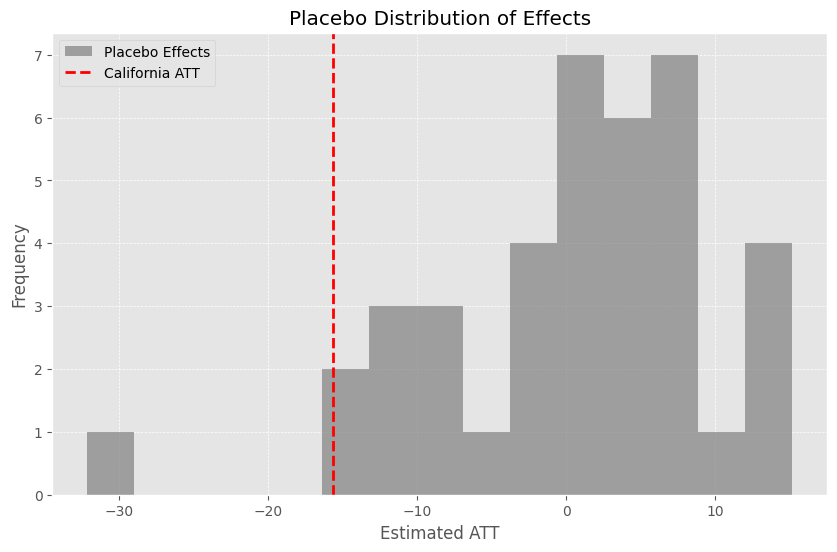

In [ ]:
# 플라시보 분포 시각화를 위한 계산
real_att = fit_model.att
control_states = df[df['treated'] == 0]['State'].unique()

placebo_atts = []
for state in tqdm(control_states):
    df_placebo = df.copy()
    df_placebo['treated_placebo'] = 0
    df_placebo.loc[(df_placebo['State'] == state) & (df_placebo['Year'] > 1988), 'treated_placebo'] = 1
    
    try:
        # 플라시보 모델 적합 및 ATT 저장
        fit_placebo = Synthdid(df_placebo, "State", "Year", "treated_placebo", "PacksPerCapita").fit()
        placebo_atts.append(fit_placebo.att)
    except Exception as e:
        continue

# 플라시보 분포 시각화
plt.figure(figsize=(10, 6))
plt.hist(placebo_atts, bins=15, color='gray', alpha=0.7, label='Placebo Effects')

# 실제 캘리포니아의 효과를 붉은색 수직선으로 표시
plt.axvline(x=real_att, color='red', linestyle='--', linewidth=2, label='California ATT')

plt.title("Placebo Distribution of Effects")
plt.xlabel("Estimated ATT")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

### 질문이나 의견을 남겨주세요.
<script src="https://utteranc.es/client.js"
        repo="CausalInferenceLab/awesome-causal-inference-python"
        issue-term="pathname"
        theme="github-light"
        crossorigin="anonymous"
        async>
</script>